### 下载所需要的包

In [39]:
# pip install pandas 
! pip install numpy

# Step 1. Data understanding：

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1.1 读取数据

In [41]:
df = pd.read_csv("stock_data_350.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"])

# keep recent 5 years
df = df[df["Date"] >= "2020-01-01"].copy()

In [42]:
df

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2020-01-02,A,85.900002,86.349998,85.199997,85.949997,82.210464,1410500.0
1,2020-01-03,A,84.669998,85.330002,84.500000,84.570000,80.890480,1118300.0
2,2020-01-06,A,84.000000,84.820000,83.599998,84.820000,81.129623,1993200.0
3,2020-01-07,A,83.959999,85.260002,83.940002,85.080002,81.378319,1684700.0
4,2020-01-08,A,85.959999,86.470001,85.199997,85.919998,82.181763,1847600.0
...,...,...,...,...,...,...,...,...
433658,2024-12-24,XOM,106.519997,107.190002,105.699997,106.400002,101.953667,7807000.0
433659,2024-12-26,XOM,106.519997,107.029999,105.940002,106.489998,102.039902,9652400.0
433660,2024-12-27,XOM,106.300003,107.989998,105.769997,106.480003,102.030327,11943900.0
433661,2024-12-30,XOM,106.300003,106.559998,105.510002,105.760002,101.340408,11080800.0


In [ ]:
## 描述数据模型
df.shape

(433663, 8)

In [ ]:
# 检查数据的行数
df.columns

Index(['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj Close',
       'Volume'],
      dtype='str')

In [ ]:
# 检查数据类型
df.dtypes

Date         datetime64[us]
Ticker                  str
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume              float64
dtype: object

In [ ]:
# 打印前几行数据，用来检查
df.head()

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2020-01-02,A,85.900002,86.349998,85.199997,85.949997,82.210464,1410500.0
1,2020-01-03,A,84.669998,85.330002,84.500000,84.570000,80.890480,1118300.0
2,2020-01-06,A,84.000000,84.820000,83.599998,84.820000,81.129623,1993200.0
3,2020-01-07,A,83.959999,85.260002,83.940002,85.080002,81.378319,1684700.0
4,2020-01-08,A,85.959999,86.470001,85.199997,85.919998,82.181763,1847600.0


In [ ]:
#检查使用的数据区间
df["Date"].min(), df["Date"].max()

(Timestamp('2020-01-02 00:00:00'), Timestamp('2024-12-31 00:00:00'))

In [ ]:
# 检查一共有多少条数据
df["Ticker"].nunique()

346

In [ ]:
# 检查股票的只数
df["Ticker"].unique()

<StringArray>
[   'A', 'AAPL', 'ABBV', 'ABNB',  'ABT', 'ACGL',  'ACN', 'ADBE',  'ADI',
  'ADM',
 ...
  'TXN',  'UNH',  'UNP',  'UPS',  'USB',    'V',   'VZ',  'WFC',  'WMT',
  'XOM']
Length: 346, dtype: str

In [ ]:
# 检查是否有缺失值
df.isnull().sum()

Date         0
Ticker       0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [ ]:
# 检查是否有重复值
df.duplicated().sum()

np.int64(0)

In [ ]:
# 每只股票各有多少行记录
df.groupby("Ticker").size().describe()

count     346.000000
mean     1253.361272
std        50.392599
min       513.000000
25%      1258.000000
50%      1258.000000
75%      1258.000000
max      1258.000000
dtype: float64

In [ ]:
# 找到数量最少的几只股票
df.groupby("Ticker").size().sort_values().head(10)

Ticker
GEHC     513
CEG      742
ABNB    1020
OTIS    1205
CARR    1205
TSLA    1258
TMUS    1258
TGT     1258
T       1258
STZ     1258
dtype: int64

In [ ]:
# 数据描述其他的feature
df[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].describe()

,Open,High,Low,Close,Adj Close,Volume
count,433663.000000,433663.000000,433663.000000,433663.000000,433663.000000,4.336630e+05
mean,148.554354,150.309311,146.766184,148.561315,140.953857,8.036504e+06
std,183.887562,185.956816,181.758246,183.910249,181.712072,3.010858e+07
min,4.040000,4.160000,3.800000,4.010000,3.009994,0.000000e+00
25%,54.970001,55.639999,54.230000,54.950001,49.535585,1.198500e+06
50%,99.209999,100.430000,97.989998,99.190002,92.491440,2.568000e+06
75%,181.929993,184.059998,179.679993,181.886864,171.260925,6.094250e+06
max,3369.000000,3416.709961,3345.439941,3370.270020,3370.270020,1.543911e+09


# Step 2. Data cleaning：

In [ ]:
# 将数据转化成时间数据
df["Date"] = pd.to_datetime(df["Date"])

In [56]:
# 3. sort by ticker and date
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)


In [ ]:
# 4. 基础检查
print("Original shape:", df.shape)
print("Number of tickers:", df["Ticker"].nunique())
print("Missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Ticker-Date rows:", df.duplicated(subset=["Ticker", "Date"]).sum())

Original shape: (433663, 8)
Number of tickers: 346
Missing values:
 Date         0
Ticker       0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
Duplicate rows: 0
Duplicate Ticker-Date rows: 0


In [ ]:
# 5. 删除为0的行
price_cols = ["Open", "High", "Low", "Close", "Adj Close"]

for col in price_cols:
    df = df[df[col] > 0]

# 删除零值或者负值
df = df[df["Volume"] > 0]


In [ ]:
# 6. 删除记录比1200少的股票
obs_count = df.groupby("Ticker").size()
valid_tickers = obs_count[obs_count >= 1200].index

removed_tickers = obs_count[obs_count < 1200].index.tolist()
print("Removed tickers (history too short):", removed_tickers)

df_clean = df[df["Ticker"].isin(valid_tickers)].copy()

Removed tickers (history too short): ['ABNB', 'CEG', 'GEHC']


In [60]:
# 7. final check
print("Cleaned shape:", df_clean.shape)
print("Remaining tickers:", df_clean["Ticker"].nunique())

print("\nObservation count after cleaning:")
print(df_clean.groupby("Ticker").size().describe())

Cleaned shape: (431386, 8)
Remaining tickers: 343

Observation count after cleaning:
count     343.000000
mean     1257.685131
std         4.041450
min      1205.000000
25%      1258.000000
50%      1258.000000
75%      1258.000000
max      1258.000000
dtype: float64


In [61]:
# 每只股票记录数是否更一致
df_clean.groupby("Ticker").size().sort_values().head(10)

Ticker
OTIS    1205
CARR    1205
CNC     1257
CCI     1257
UNP     1258
UNH     1258
TXN     1258
TSLA    1258
TMUS    1258
TGT     1258
dtype: int64

# Step 3. Feature engineering：

In [ ]:
# 阅读已经清洗之后的数据
df_clean["Date"] = pd.to_datetime(df_clean["Date"])
df_clean = df_clean.sort_values(["Ticker", "Date"]).reset_index(drop=True)

In [ ]:
# 提取每天层面的行为特征
df_clean["daily_return"] = df_clean.groupby("Ticker")["Adj Close"].pct_change()
df_clean["abs_return"] = df_clean["daily_return"].abs()
df_clean["log_volume"] = np.log1p(df_clean["Volume"])
df_clean["price_range"] = (df_clean["High"] - df_clean["Low"]) / df_clean["Open"]


In [ ]:
# 使用SPY来作为基准
spy_returns = (
    df_clean[df_clean["Ticker"] == "SPY"][["Date", "daily_return"]]
    .rename(columns={"daily_return": "spy_return"})
)

df_clean = df_clean.merge(spy_returns, on="Date", how="left")

In [ ]:
# 删除掉缺失值
df_model = df_clean.dropna(subset=["daily_return"]).copy()

In [ ]:
# 计算每只股票在整个样本期间的累计收益率
trend_df = (
    df_clean.groupby("Ticker")
    .agg(
        first_adj_close=("Adj Close", "first"),
        last_adj_close=("Adj Close", "last")
    )
    .reset_index()
)

trend_df["trend_return"] = (
    trend_df["last_adj_close"] / trend_df["first_adj_close"] - 1
)

trend_df = trend_df[["Ticker", "trend_return"]]

In [ ]:
# 计算每只股票和 SPY 的日收益率相关系数
corr_list = []

for ticker, group in df_model.groupby("Ticker"):
    corr = group["daily_return"].corr(group["spy_return"])
    corr_list.append([ticker, corr])

corr_df = pd.DataFrame(corr_list, columns=["Ticker", "market_corr"])

In [ ]:
# 将所有的特征聚合在一起
feature_df = feature_df.merge(trend_df, on="Ticker", how="left")
feature_df = feature_df.merge(corr_df, on="Ticker", how="left")

In [ ]:
#  从最终聚类数据集中删除SPY
feature_df = feature_df[feature_df["Ticker"] != "SPY"].copy()

# Step 4. Exploratory analysis：

In [97]:
# ! pip install matplotlib
# ! pip install seaborn
# ! pip install sklearn

In [ ]:
print("Shape:", feature_df.shape)
print("\nHead:")
print(feature_df.head())

print("\nMissing values:")
print(feature_df.isnull().sum())

print("\nSummary statistics:")
print(feature_df.describe())

Shape: (342, 10)

Head:
  Ticker  mean_return  return_volatility  avg_abs_return  \
0      A     0.000557           0.018689        0.013490   
1   AAPL     0.001182           0.019956        0.014064   
2   ABBV     0.000839           0.015613        0.010644   
3    ABT     0.000414           0.016469        0.011417   
4   ACGL     0.000870           0.021334        0.014212   

   positive_return_ratio  avg_log_volume  volume_volatility  price_range_mean  \
0               0.528242       14.288650           0.397404          0.022991   
1               0.533015       18.193167           0.484622          0.022455   
2               0.543357       15.627346           0.420658          0.020144   
3               0.511535       15.466207           0.382363          0.019713   
4               0.537788       14.372062           0.448544          0.024015   

   trend_return  market_corr  
0      0.617359     0.680958  
1      2.440023     0.790628  
2      1.459009     0.458288  
3   

## 画直方图看分布

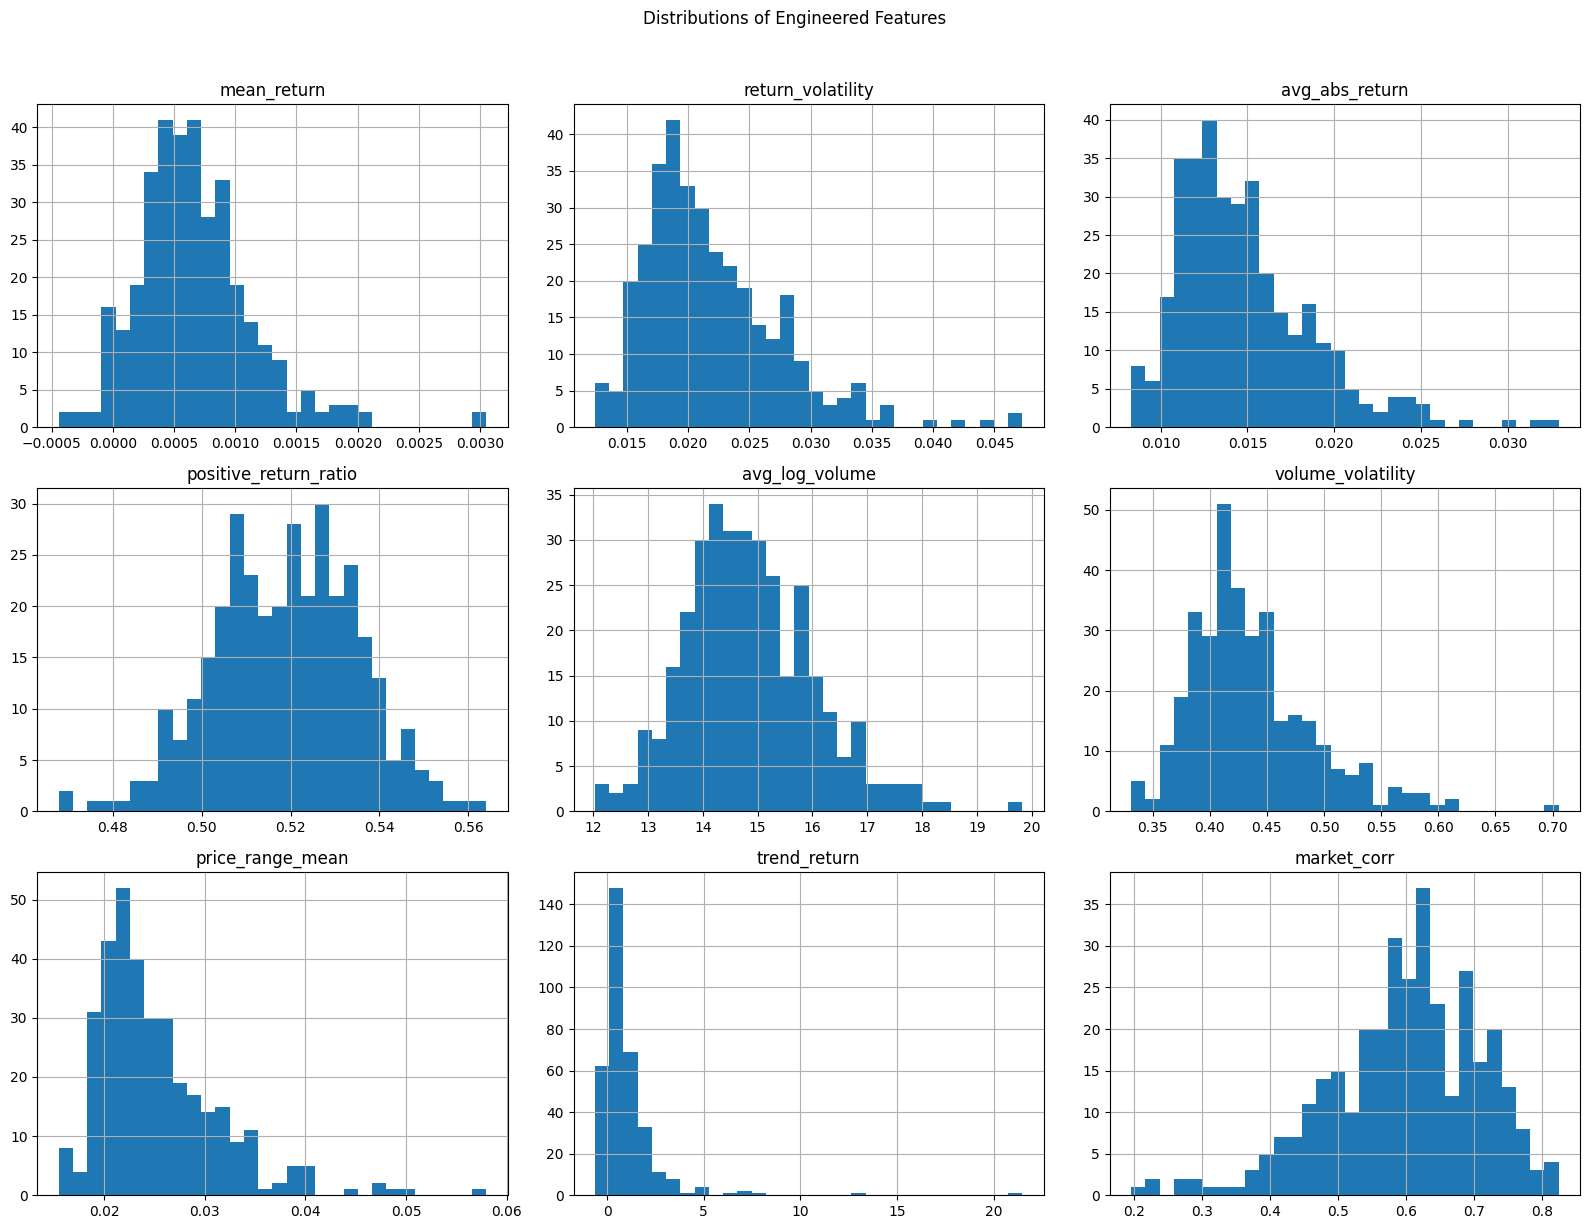

In [ ]:
# 画出每个数据的直方图
num_cols = [col for col in feature_df.columns if col != "Ticker"]

feature_df[num_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle("Distributions of Engineered Features", y=1.02)
plt.tight_layout()
plt.show()

## 画箱线图看异常值

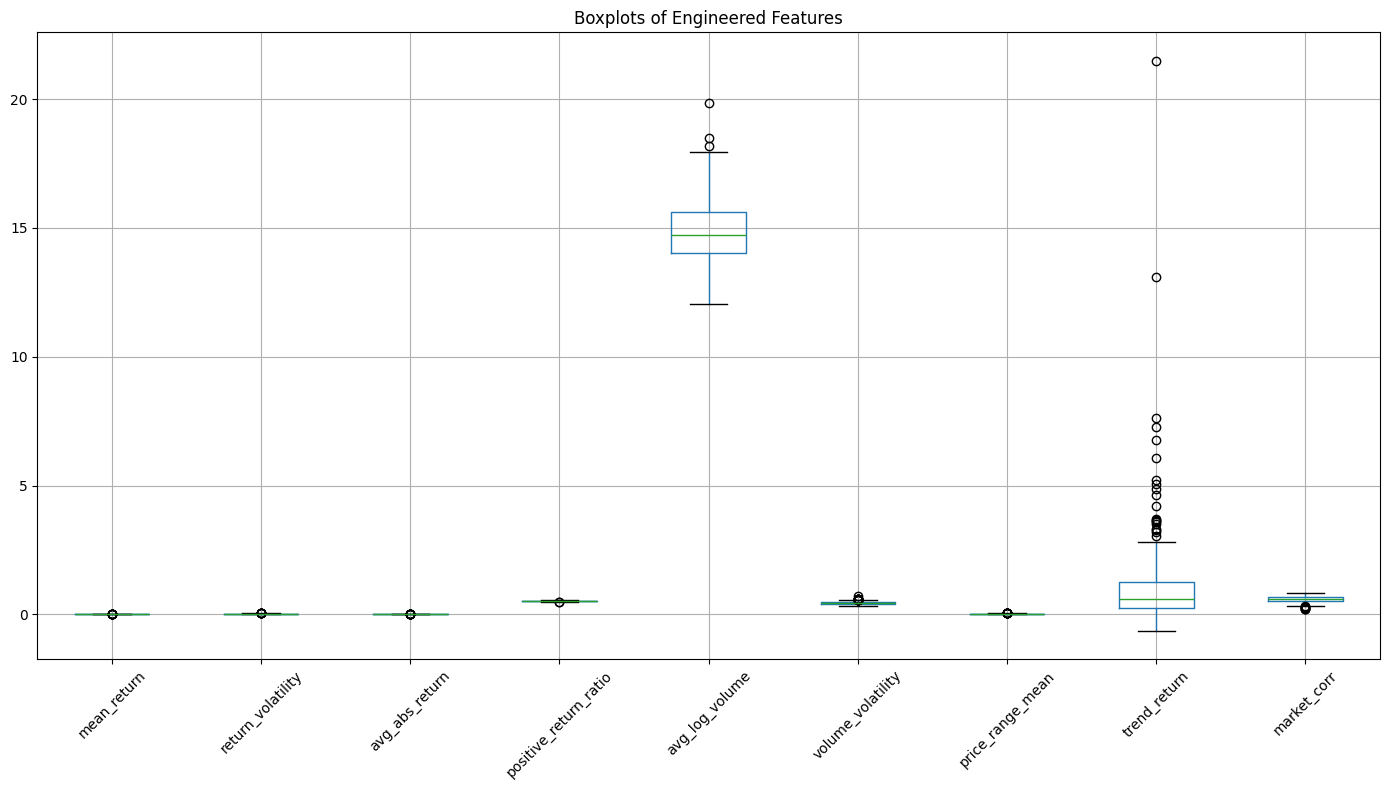

In [ ]:
# 画出箱线图看异常值
plt.figure(figsize=(14, 8))
feature_df[num_cols].boxplot(rot=45)
plt.title("Boxplots of Engineered Features")
plt.tight_layout()
plt.show()

# Step 5. Preprocessing for clustering：

In [ ]:
# keep ticker separately
cluster_features = [
    "mean_return",
    "return_volatility",
    "avg_abs_return",
    "positive_return_ratio",
    "avg_log_volume",
    "volume_volatility",
    "price_range_mean",
    "market_corr"
]

cluster_df = feature_df[["Ticker"] + cluster_features].copy()

# save tickers
tickers = cluster_df["Ticker"].values

# 手动做数据标准化
X = cluster_df[cluster_features]
X_scaled = (X - X.mean()) / X.std()

# make scaled dataframe
scaled_df = X_scaled.copy()
scaled_df.insert(0, "Ticker", tickers)

print(scaled_df.head())

  Ticker  mean_return  return_volatility  avg_abs_return  \
0      A    -0.233534          -0.576508       -0.340696   
1   AAPL     1.094975          -0.350318       -0.194680   
2   ABBV     0.365837          -1.125629       -1.065405   
3    ABT    -0.537589          -0.972766       -0.868685   
4   ACGL     0.431334          -0.104223       -0.156857   

   positive_return_ratio  avg_log_volume  volume_volatility  price_range_mean  \
0               0.579149       -0.479306          -0.719209         -0.380787   
1               0.876315        2.848021           0.892470         -0.468549   
2               1.520173        0.661496          -0.289505         -0.847036   
3              -0.460930        0.524177          -0.997146         -0.917636   
4               1.173480       -0.408224           0.225797         -0.213106   

   market_corr  
0     0.743754  
1     1.720266  
2    -1.238926  
3     0.150802  
4     0.174570  


# Step 6. Clustering：

In [ ]:
# -----------------------------
# 1. K-means helper functions
# -----------------------------

def euclidean_distance_matrix(X, centroids):
    """
    计算每个样本点到每个聚类中心的欧式距离。

    参数：
    X : shape (n, p)
        n 个样本，p 个特征
    centroids : shape (k, p)
        k 个聚类中心，每个中心有 p 个特征

    返回：
    distances : shape (n, k)
        第 i 行第 j 列表示：第 i 个样本到第 j 个中心的距离
    """
    return np.sqrt(((X[:, np.newaxis, :] - centroids[np.newaxis, :, :]) ** 2).sum(axis=2))


def compute_inertia(X, labels, centroids):
    """
    计算当前聚类结果的 inertia（簇内平方和）。

    inertia 越小，说明同一簇内的点越紧密。

    参数：
    X : shape (n, p)
        所有样本点
    labels : shape (n,)
        每个样本所属的簇标签
    centroids : shape (k, p)
        k 个聚类中心

    返回：
    inertia : float
        所有簇内样本到各自中心的平方距离之和
    """
    inertia = 0.0
    
    # 遍历每一个簇
    for k in range(len(centroids)):
        # 取出属于第 k 个簇的所有样本点
        cluster_points = X[labels == k]
        
        # 如果这个簇里有点，才计算平方距离和
        if len(cluster_points) > 0:
            inertia += ((cluster_points - centroids[k]) ** 2).sum()
    
    return inertia


def kmeans_numpy(X, k, max_iter=100, tol=1e-4, random_state=42, n_init=10):
    """
    用 numpy 手写 K-means 聚类。

    参数：
    X : shape (n, p)
        输入数据，n 个样本，p 个特征
    k : int
        聚类个数
    max_iter : int
        每次初始化后最多迭代多少次
    tol : float
        收敛阈值；如果新旧中心移动距离小于这个值，就停止迭代
    random_state : int
        随机种子，保证结果可复现
    n_init : int
        随机初始化多少次，最后选 inertia 最小的那一次

    返回：
    best_labels : shape (n,)
        最优聚类结果中每个样本的簇标签
    best_centroids : shape (k, p)
        最优聚类结果中的聚类中心
    best_inertia : float
        最优聚类结果对应的 inertia
    """
    
    # 创建随机数生成器
    rng = np.random.default_rng(random_state)
    
    # 初始化“最优结果”
    best_inertia = np.inf
    best_labels = None
    best_centroids = None
    
    # 重复做 n_init 次随机初始化，避免陷入差的局部最优
    for _ in range(n_init):
        
        # -----------------------------
        # Step 1: 随机选 k 个样本作为初始中心
        # -----------------------------
        init_idx = rng.choice(len(X), size=k, replace=False)
        centroids = X[init_idx].copy()
        
        # -----------------------------
        # Step 2: 迭代更新簇标签和中心
        # -----------------------------
        for _ in range(max_iter):
            
            # 2.1 计算每个样本到每个中心的距离
            distances = euclidean_distance_matrix(X, centroids)
            
            # 2.2 把每个样本分配给最近的中心
            labels = distances.argmin(axis=1)
            
            # 2.3 根据新的簇分配，重新计算每个簇的中心
            new_centroids = np.array([
                X[labels == j].mean(axis=0) if np.any(labels == j) else centroids[j]
                for j in range(k)
            ])
            
            # 2.4 计算新旧中心的整体移动距离
            shift = np.sqrt(((new_centroids - centroids) ** 2).sum())
            
            # 更新中心
            centroids = new_centroids
            
            # 2.5 如果中心移动很小，说明已经收敛，停止迭代
            if shift < tol:
                break
        
        # -----------------------------
        # Step 3: 计算本次初始化的 inertia
        # -----------------------------
        inertia = compute_inertia(X, labels, centroids)
        
        # -----------------------------
        # Step 4: 如果这次结果更好，就保存下来
        # -----------------------------
        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels.copy()
            best_centroids = centroids.copy()
    
    # 返回最好的聚类结果
    return best_labels, best_centroids, best_inertia

In [ ]:
def pairwise_distances(X):
    """
    计算所有样本两两之间的欧式距离矩阵。

    参数：
    X : shape (n, p)
        n 个样本，p 个特征

    返回：
    D : shape (n, n)
        第 i 行第 j 列表示：第 i 个样本到第 j 个样本的距离
    """
    
    # 利用广播机制，构造所有样本两两之差
    # X[:, np.newaxis, :] 形状变成 (n, 1, p)
    # X[np.newaxis, :, :] 形状变成 (1, n, p)
    # 相减后得到 (n, n, p)，表示每对样本在每个特征上的差值
    diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]
    
    # 对每对样本的差值平方、按特征求和、再开根号
    # 最终得到 (n, n) 的距离矩阵
    return np.sqrt((diff ** 2).sum(axis=2))


def silhouette_score_numpy(X, labels):
    """
    用 numpy 手动计算 silhouette score（轮廓系数）。

    silhouette score 用来评估聚类质量：
    - 同一簇内的点是否彼此接近
    - 不同簇之间的点是否彼此分开

    参数：
    X : shape (n, p)
        n 个样本，p 个特征
    labels : shape (n,)
        每个样本所属的簇标签

    返回：
    score : float
        所有样本 silhouette 值的平均值
    """
    
    # 样本数量
    n = len(X)
    
    # 获取所有不同的簇标签
    unique_labels = np.unique(labels)
    
    # 如果只有 1 个簇，silhouette score 没有意义，返回 NaN
    if len(unique_labels) < 2:
        return np.nan
    
    # 先计算所有样本之间的距离矩阵
    D = pairwise_distances(X)
    
    # 用来存每个样本的 silhouette 值
    sil_scores = []
    
    # 遍历每一个样本 i
    for i in range(n):
        
        # 找出和样本 i 属于同一个簇的样本
        same_cluster = labels == labels[i]
        
        # 把自己排除掉，因为自己到自己的距离是 0，不能算进去
        same_cluster[i] = False
        
        # -----------------------------
        # Step 1: 计算 a(i)
        # a(i) = 样本 i 到“同簇其他样本”的平均距离
        # 表示它和自己这一类有多接近
        # -----------------------------
        if np.sum(same_cluster) > 0:
            a_i = D[i, same_cluster].mean()
        else:
            # 如果这个簇只有它自己一个点，就令 a(i)=0
            a_i = 0.0
        
        # -----------------------------
        # Step 2: 计算 b(i)
        # b(i) = 样本 i 到“最近的其他簇”的平均距离
        # 表示它和别的类有多远
        # -----------------------------
        b_i = np.inf
        
        # 遍历其他所有簇
        for c in unique_labels:
            # 跳过自己所在的簇
            if c == labels[i]:
                continue
            
            # 找出属于簇 c 的所有样本
            other_cluster = labels == c
            
            # 如果这个簇里有样本
            if np.sum(other_cluster) > 0:
                # 计算样本 i 到簇 c 所有样本的平均距离
                dist_to_cluster = D[i, other_cluster].mean()
                
                # 取所有其他簇中最小的平均距离
                b_i = min(b_i, dist_to_cluster)
        
        # -----------------------------
        # Step 3: 计算 silhouette 值
        # s(i) = (b(i) - a(i)) / max(a(i), b(i))
        # 值越接近 1 越好，越接近 0 越模糊，小于 0 可能分错
        # -----------------------------
        sil_i = (b_i - a_i) / max(a_i, b_i) if max(a_i, b_i) > 0 else 0
        
        # 保存当前样本的 silhouette 值
        sil_scores.append(sil_i)
    
    # 返回所有样本 silhouette 值的平均数
    return np.mean(sil_scores)

In [ ]:
# -----------------------------
# 把标准化后的特征矩阵转换成 numpy array
# 因为我们手写的 K-means 函数是按 numpy array 来处理的
# -----------------------------
if isinstance(X_scaled, pd.DataFrame):
    # 如果 X_scaled 还是 DataFrame，就提取里面的数值部分
    X_array = X_scaled.values
else:
    # 如果本来就是 numpy array，就直接用
    X_array = X_scaled

# 用来保存不同 k 值下的聚类结果
results = []

# -----------------------------
# 依次测试不同的聚类个数 k
# 这里测试 k = 3, 4, 5, 6, 7, 8
# -----------------------------
for k in range(3, 9):
    
    # 运行手写的 K-means
    # 返回：
    # labels     -> 每个样本被分到哪个 cluster
    # centroids  -> 每个 cluster 的中心点
    # inertia    -> 簇内平方和，越小通常表示类内越紧密
    labels, centroids, inertia = kmeans_numpy(
        X_array, k=k, max_iter=100, tol=1e-4, random_state=42, n_init=10
    )
    
    # 计算当前 k 下的 silhouette score
    # 用来衡量聚类分得清不清楚，通常越大越好
    sil = silhouette_score_numpy(X_array, labels)
    
    # 统计每个 cluster 里有多少只股票
    # 例如可能得到 {0: 80, 1: 120, 2: 143}
    cluster_sizes = pd.Series(labels).value_counts().sort_index().to_dict()
    
    # 把当前 k 的结果保存到列表中
    results.append({
        "k": k,                           # 当前聚类个数
        "inertia": inertia,               # 当前 k 下的 inertia
        "silhouette_score": sil,          # 当前 k 下的 silhouette score
        "cluster_sizes": cluster_sizes    # 当前 k 下每个 cluster 的大小
    })

# 把所有 k 的结果整理成 DataFrame，方便比较
results_df = pd.DataFrame(results)

# 显示结果表
results_df

,k,inertia,silhouette_score,cluster_sizes
0,3,1667.720224,0.189757,"{0: 104, 1: 83, 2: 155}"
1,4,1486.175544,0.175813,"{0: 72, 1: 137, 2: 85, 3: 48}"
2,5,1346.077848,0.178081,"{0: 18, 1: 45, 2: 70, 3: 123, 4: 86}"
3,6,1255.285850,0.181694,"{0: 20, 1: 62, 2: 53, 3: 127, 4: 29, 5: 51}"
4,7,1171.325303,0.161974,"{0: 83, 1: 38, 2: 69, 3: 32, 4: 41, 5: 59, 6: 20}"
5,8,1098.373520,0.155715,"{0: 17, 1: 60, 2: 42, 3: 68, 4: 32, 5: 51, 6: ..."


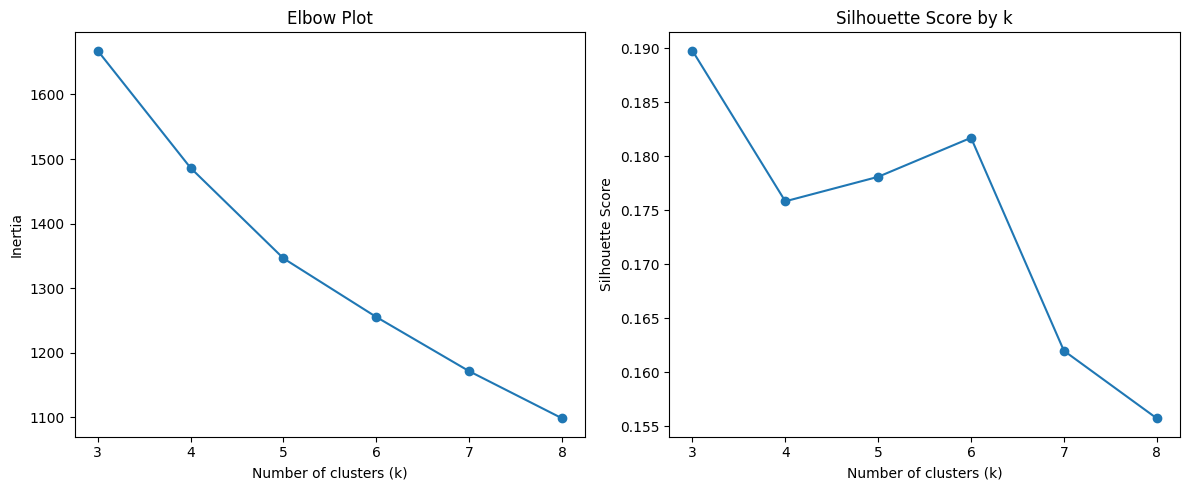

In [100]:
# 创建一个画布，整体大小为 12 x 5
# 这里准备在同一行放两个图
plt.figure(figsize=(12, 5))

# -----------------------------
# 第一个子图：Elbow Plot
# -----------------------------
# 表示 1 行 2 列中的第 1 个图
plt.subplot(1, 2, 1)

# 横轴是聚类个数 k
# 纵轴是对应的 inertia
# marker="o" 表示在每个点上画圆点
plt.plot(results_df["k"], results_df["inertia"], marker="o")

# 设置图标题
plt.title("Elbow Plot")

# 设置横轴标签
plt.xlabel("Number of clusters (k)")

# 设置纵轴标签
plt.ylabel("Inertia")


# -----------------------------
# 第二个子图：Silhouette Score Plot
# -----------------------------
# 表示 1 行 2 列中的第 2 个图
plt.subplot(1, 2, 2)

# 横轴是聚类个数 k
# 纵轴是对应的 silhouette score
plt.plot(results_df["k"], results_df["silhouette_score"], marker="o")

# 设置图标题
plt.title("Silhouette Score by k")

# 设置横轴标签
plt.xlabel("Number of clusters (k)")

# 设置纵轴标签
plt.ylabel("Silhouette Score")

# 自动调整子图之间的间距，避免标题和标签重叠
plt.tight_layout()

# 显示图形
plt.show()

In [99]:
# 最好的分类数
best_k = results_df.loc[results_df["silhouette_score"].idxmax(), "k"]
print("Best k based on silhouette score:", best_k)

Best k based on silhouette score: 3


# Step 7. Cluster interpretation：